Now we will perform the Exploratory data analysis on the features against the target variables & also replace the missing values-

1. encode all the variables

2. eda of in which month customers were churning the most? any seasonality.

3. PCA to find correlation of the variable - part of feature engineering.

4. Replace UsageData & BillingAmount NaNs with the mean of contractType of that column.

5. Binning of the demographic columns, age & Income.

6. assign churn risk score probability from 0-100%.

7. Binning of churn prediction

In [86]:
import sys, os, glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
# importing nessaary util functions
from utils.utils import plot_feature_comparison
sys.path.append(os.path.abspath(os.path.join(os.path.dirname("../"), ".")))
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [105]:
# processed_df_path should go in the config.yaml
processed_df_path = "../data/processed/churn_data_processed.csv"
df = pd.read_csv(processed_df_path)

In [106]:
df.dtypes

UsageData                      float64
BillingAmount                  float64
PaymentHistory                   int64
CustomerServiceInteractions      int64
Complaints                       int64
PromotionsReceived               int64
ContractType                     int64
ContractDuration                 int64
Age                              int64
Gender                           int64
Income                           int64
HouseholdSize                    int64
is_churned                       int64
Month                            int64
dtype: object

In [88]:
df.head()

,UsageData,BillingAmount,PaymentHistory,CustomerServiceInteractions,Complaints,PromotionsReceived,ContractType,ContractDuration,Age,Gender,Income,HouseholdSize,is_churned,Month
0,880.922970,NaN,1,2,0,0,1,16,18,0,57732,2,0,1
1,NaN,176.144725,1,1,0,2,1,12,51,0,84085,3,0,1
2,311.763191,145.690171,1,2,0,0,0,15,21,1,51898,5,0,1
3,414.412773,105.305217,1,4,1,3,1,13,23,0,72227,3,0,1
4,244.697028,52.308319,1,5,2,3,0,17,41,1,37707,1,0,1


#### Plotting relationship between behaviour of churned users vs exisiting users

/Users/akshaysharma/Documents/forecast_customer_churn/forecasting_customer_churn/utils/utils.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=group_avg, x=x_col, y=y_col, palette=palette)


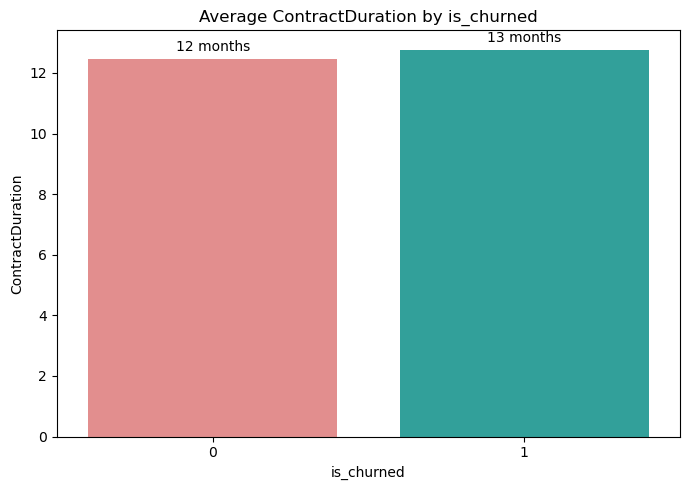

In [89]:
#plotting relationship between different behaviour of churned users
plot_feature_comparison(df    = df,
                        x_col = 'is_churned',
                        y_col = 'ContractDuration')

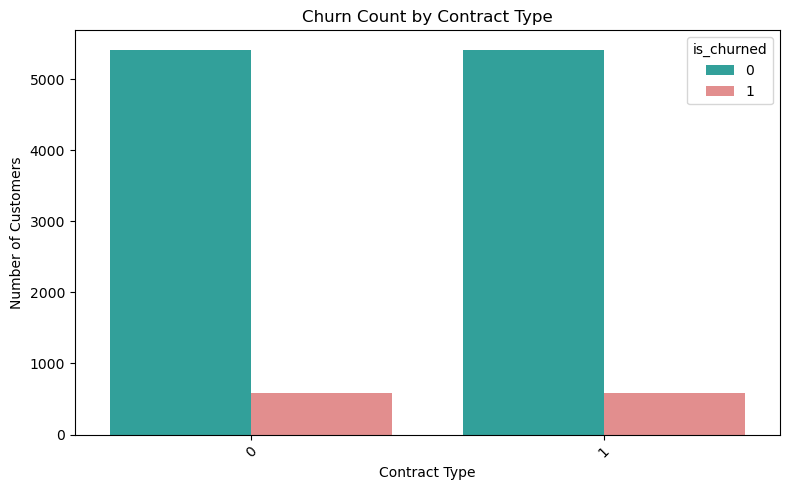

In [90]:
# Side-by-side bar plot
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='ContractType', hue='is_churned', palette=['#20B2AA', '#F08080'])
plt.title("Churn Count by Contract Type")
plt.ylabel("Number of Customers")
plt.xlabel("Contract Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [91]:
df['ContractType'].value_counts()

ContractType
1    6002
0    5998
Name: count, dtype: int64

In [92]:
df.head()

,UsageData,BillingAmount,PaymentHistory,CustomerServiceInteractions,Complaints,PromotionsReceived,ContractType,ContractDuration,Age,Gender,Income,HouseholdSize,is_churned,Month
0,880.922970,NaN,1,2,0,0,1,16,18,0,57732,2,0,1
1,NaN,176.144725,1,1,0,2,1,12,51,0,84085,3,0,1
2,311.763191,145.690171,1,2,0,0,0,15,21,1,51898,5,0,1
3,414.412773,105.305217,1,4,1,3,1,13,23,0,72227,3,0,1
4,244.697028,52.308319,1,5,2,3,0,17,41,1,37707,1,0,1


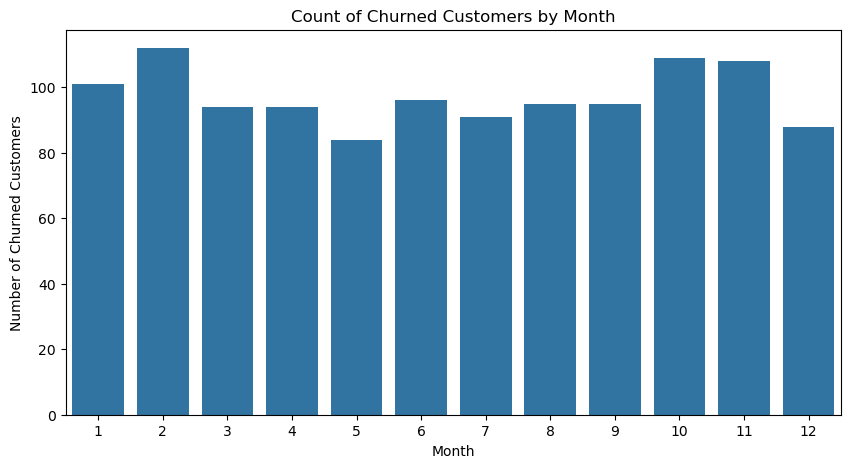

In [93]:
# Filter for churned customers only
churned_df = df[df['is_churned'] == 1]

# Plot count of churned customers by month
plt.figure(figsize=(10, 5))
sns.countplot(data=churned_df, x='Month')
plt.title("Count of Churned Customers by Month")
plt.xlabel("Month")
plt.ylabel("Number of Churned Customers")
plt.show()

In [94]:
churned_df.head()

,UsageData,BillingAmount,PaymentHistory,CustomerServiceInteractions,Complaints,PromotionsReceived,ContractType,ContractDuration,Age,Gender,Income,HouseholdSize,is_churned,Month
16,261.663414,NaN,1,4,1,0,1,10,58,1,90962,5,1,1
46,NaN,82.854081,0,4,0,3,1,17,42,1,99177,1,1,1
49,362.151951,NaN,1,3,2,0,1,20,58,1,73835,4,1,1
50,916.450499,36.167692,1,3,1,0,1,9,68,0,72518,2,1,1
64,193.085615,97.691614,1,0,2,1,0,2,21,0,83490,5,1,1


### Replace the missing values in usageData & BillingAmount
In order to replace the missing values we are first using simple median to replace the NaNs, 

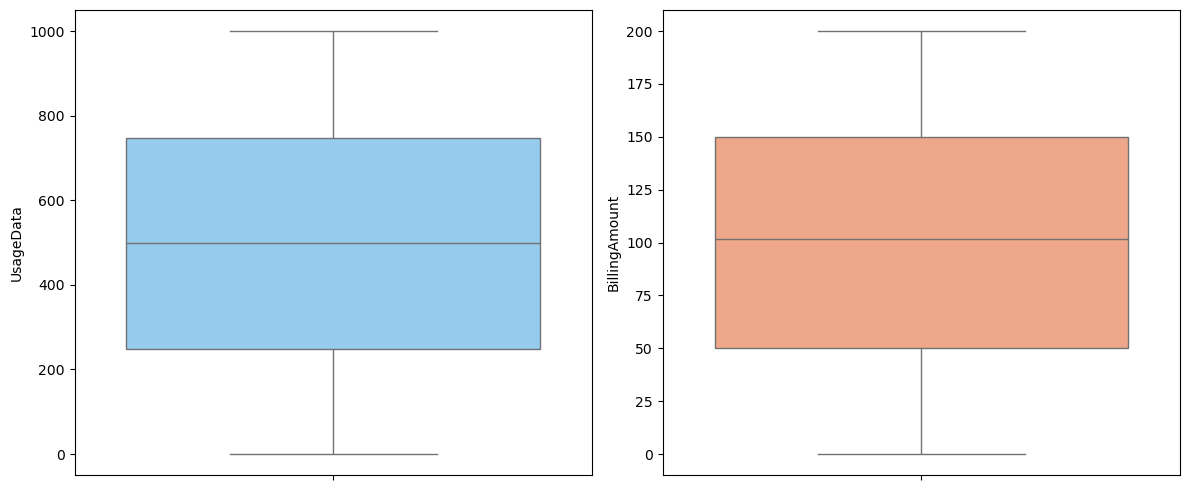

In [95]:
plt.figure(figsize=(12, 5))

# UsageData with log scale
plt.subplot(1, 2, 1)
sns.boxplot(data=df, y='UsageData', color='#87CEFA')

# BillingAmount with log scale
plt.subplot(1, 2, 2)
sns.boxplot(data=df, y='BillingAmount', color='#FFA07A')

plt.tight_layout()
plt.show()

In [ ]:
#lets replace the missing values in billing & usage data with group median of contractType
df_feature_eng = df.copy()
df_feature_eng['UsageData'] = df_feature_eng.groupby('ContractType')['UsageData'].transform(lambda x: x.fillna(x.median()))
df_feature_eng['BillingAmount'] = df_feature_eng.groupby('ContractType')['BillingAmount'].transform(lambda x: x.fillna(x.median()))

# Confirm missing values are handled
print(df[['UsageData', 'BillingAmount']].isnull().sum())

UsageData        0
BillingAmount    0
dtype: int64


### Correlation of churn with individual variables

In [97]:
# now we will plot all the continuous variables against churn column to notice the relationship of churn with individual variables
df_feature_eng[df_feature_eng['is_churned'] == 1].describe()

,UsageData,BillingAmount,PaymentHistory,CustomerServiceInteractions,Complaints,PromotionsReceived,ContractType,ContractDuration,Age,Gender,Income,HouseholdSize,is_churned,Month
count,925.000000,927.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.0,1167.000000
mean,511.217423,98.493607,0.812339,2.542416,1.010283,1.487575,0.501285,12.769494,43.261354,0.505570,73073.483290,3.163668,1.0,6.482434
std,284.371415,58.189571,0.390608,1.679166,0.830320,1.127228,0.500213,6.830526,15.039664,0.500183,23328.402875,1.510892,0.0,3.500722
min,0.866777,0.019002,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,18.000000,0.000000,25874.000000,1.000000,1.0,1.000000
25%,261.818878,46.953117,1.000000,1.000000,0.000000,0.000000,0.000000,7.000000,31.000000,0.000000,53033.500000,2.000000,1.0,3.000000
50%,525.021873,98.831687,1.000000,3.000000,1.000000,1.000000,1.000000,13.000000,44.000000,1.000000,73917.000000,3.000000,1.0,7.000000
75%,743.718415,148.319329,1.000000,4.000000,2.000000,3.000000,1.000000,19.000000,56.000000,1.000000,92341.000000,4.000000,1.0,10.000000
max,999.875654,199.804649,1.000000,6.000000,2.000000,3.000000,1.000000,24.000000,69.000000,1.000000,118248.000000,9.000000,1.0,12.000000


In [98]:
# now we will plot all the continuous variables against churn column to notice the relationship of churn with individual variables
df_feature_eng[df_feature_eng['is_churned'] == 0].describe()

,UsageData,BillingAmount,PaymentHistory,CustomerServiceInteractions,Complaints,PromotionsReceived,ContractType,ContractDuration,Age,Gender,Income,HouseholdSize,is_churned,Month
count,8675.000000,8673.000000,10833.000000,10833.000000,10833.000000,10833.000000,10833.000000,10833.000000,10833.000000,10833.000000,10833.000000,10833.000000,10833.0,10833.000000
mean,499.858442,100.654088,0.795901,2.481030,1.011816,1.482138,0.500046,12.461460,43.492015,0.503923,72972.775778,3.106434,0.0,6.501892
std,288.379517,57.570959,0.403060,1.702601,0.814524,1.127031,0.500023,6.956967,14.907710,0.500008,23491.946960,1.524913,0.0,3.447086
min,0.031196,0.005248,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,18.000000,0.000000,25451.000000,1.000000,0.0,1.000000
25%,246.410707,50.520203,1.000000,1.000000,0.000000,0.000000,0.000000,6.000000,31.000000,0.000000,53103.000000,2.000000,0.0,4.000000
50%,497.099852,101.666390,1.000000,2.000000,1.000000,1.000000,1.000000,12.000000,43.000000,1.000000,73161.000000,3.000000,0.0,6.000000
75%,747.573345,150.101165,1.000000,4.000000,2.000000,2.000000,1.000000,19.000000,56.000000,1.000000,92733.000000,4.000000,0.0,9.000000
max,999.957592,199.976431,1.000000,6.000000,2.000000,3.000000,1.000000,24.000000,69.000000,1.000000,120606.000000,9.000000,0.0,12.000000


In [104]:
df_feature_eng.dtypes

UsageData                      float64
BillingAmount                  float64
PaymentHistory                   int64
CustomerServiceInteractions      int64
Complaints                       int64
PromotionsReceived               int64
ContractType                     int64
ContractDuration                 int64
Age                              int64
Gender                           int64
Income                           int64
HouseholdSize                    int64
is_churned                       int64
Month                            int64
dtype: object

In [103]:
numeric_cols = df.select_dtypes(include=['number']).drop(columns=['is_churned']).columns
numeric_cols

Index(['UsageData', 'BillingAmount', 'PaymentHistory',
       'CustomerServiceInteractions', 'Complaints', 'PromotionsReceived',
       'ContractType', 'ContractDuration', 'Age', 'Gender', 'Income',
       'HouseholdSize', 'Month'],
      dtype='object')

/var/folders/7w/dgslt9rx39qb89n089jly0tm0000gn/T/ipykernel_46950/1206022490.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_churned', y=col, palette=['#20B2AA', '#F08080'])
/var/folders/7w/dgslt9rx39qb89n089jly0tm0000gn/T/ipykernel_46950/1206022490.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_churned', y=col, palette=['#20B2AA', '#F08080'])
/var/folders/7w/dgslt9rx39qb89n089jly0tm0000gn/T/ipykernel_46950/1206022490.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_churned', y=col, pal

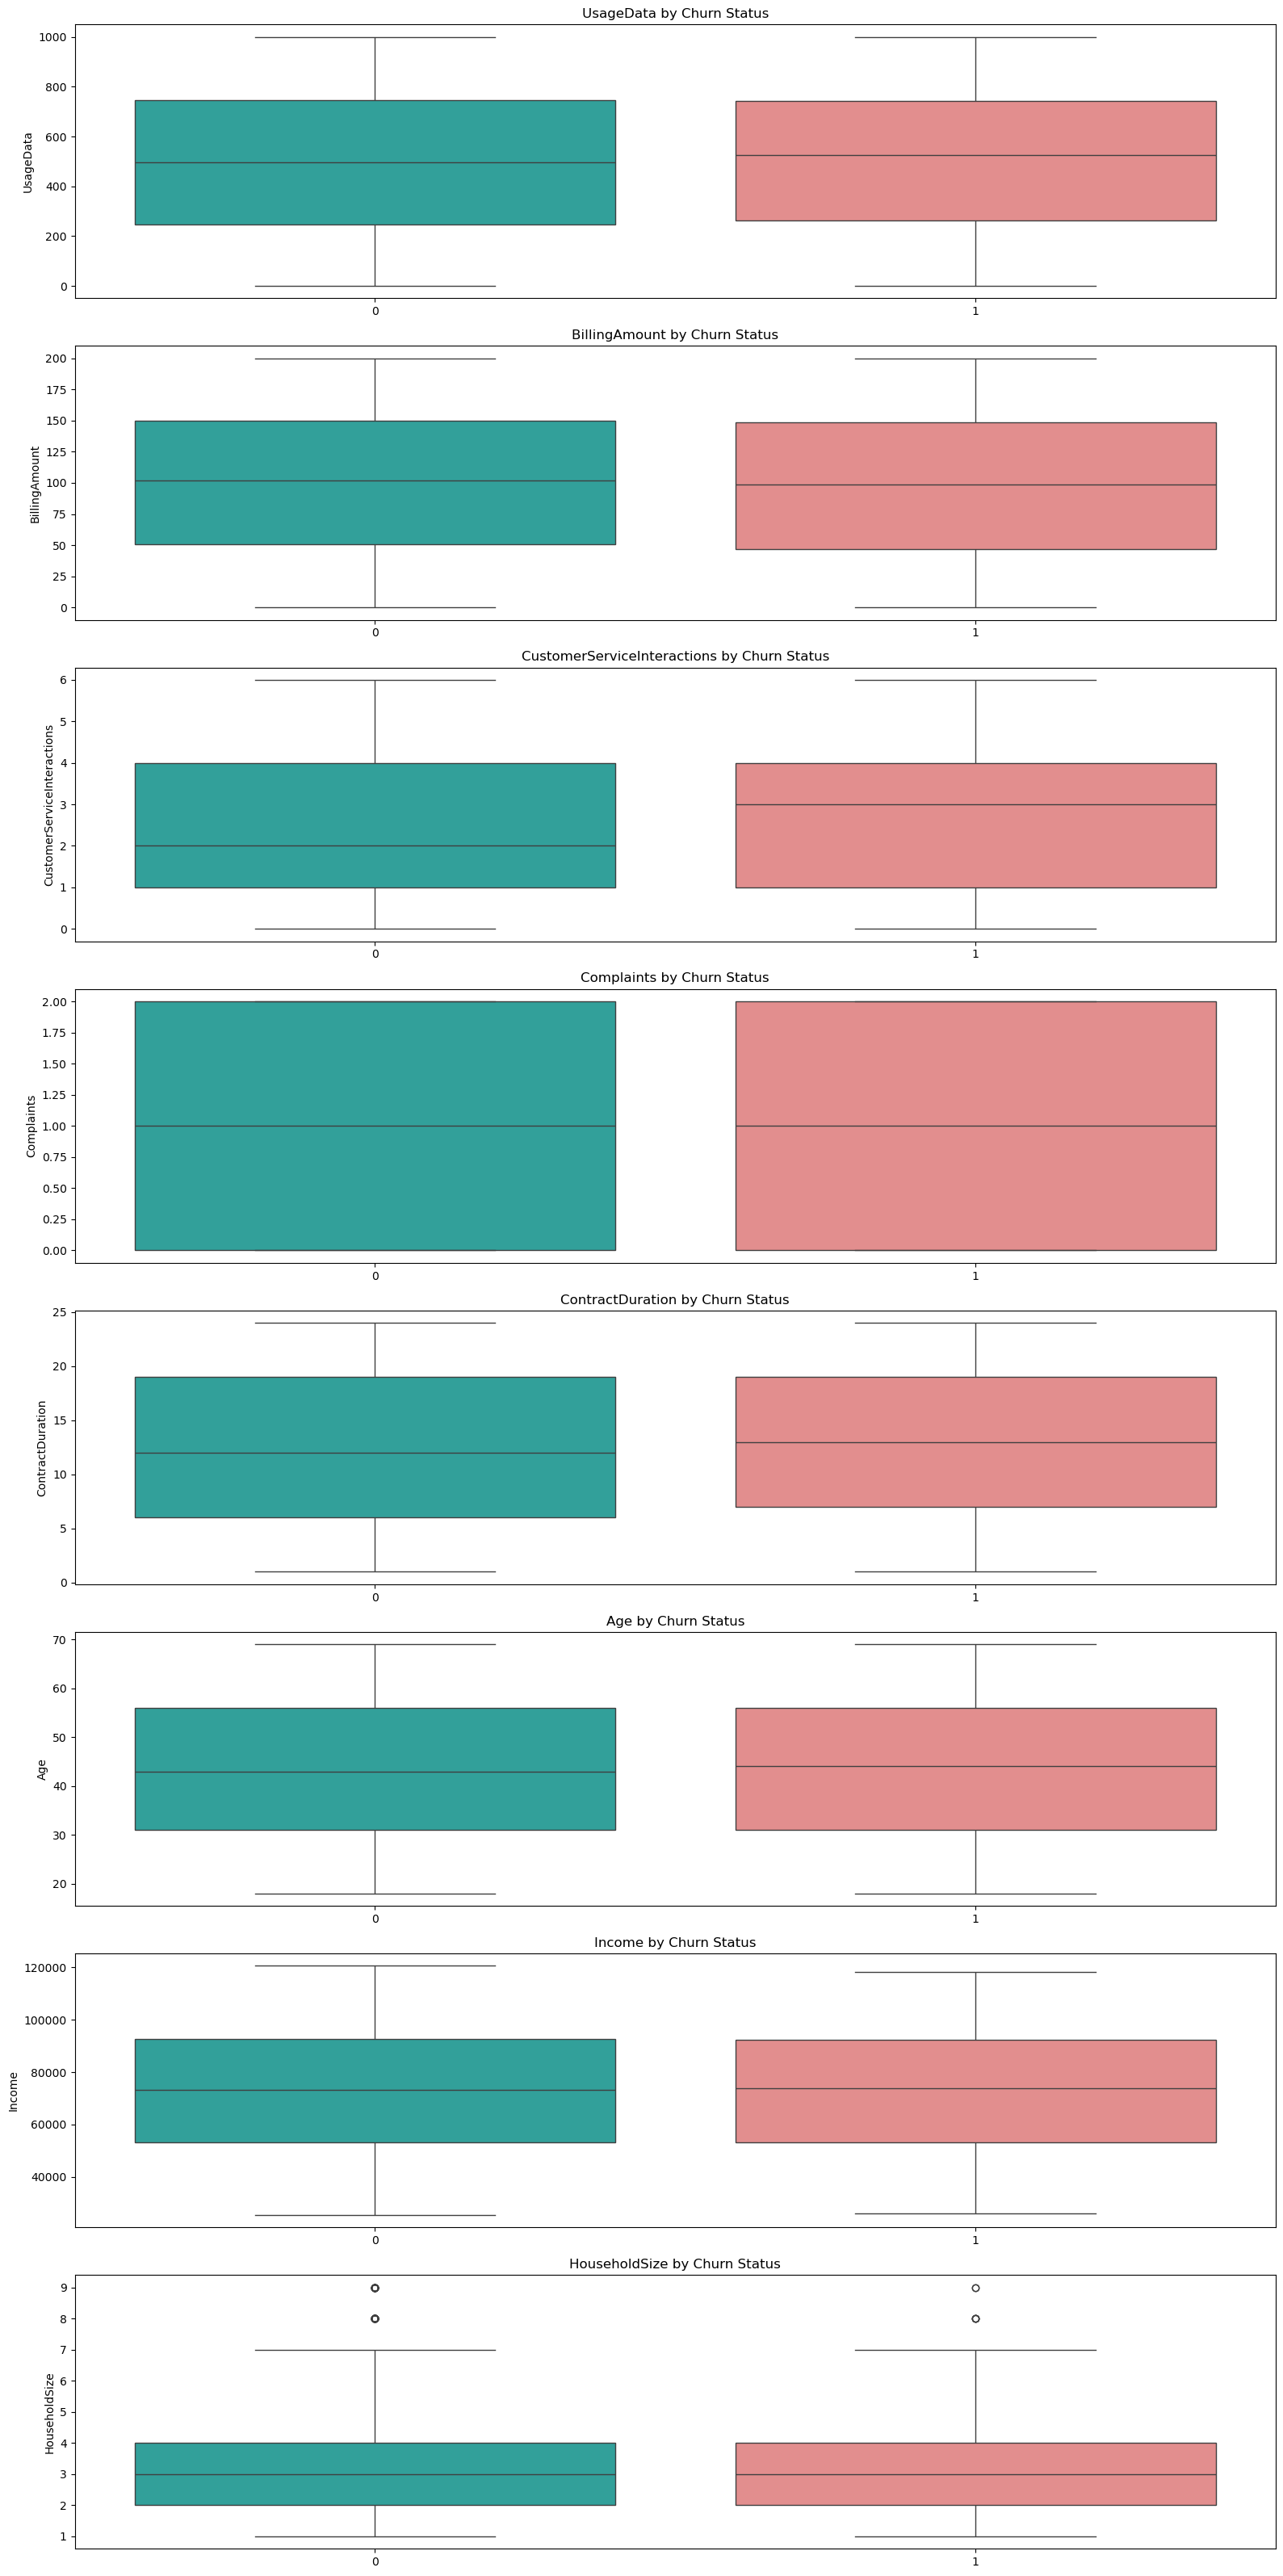

In [108]:
# Filter only numeric columns (excluding the target)
numeric_cols = ['UsageData', 'BillingAmount', 'CustomerServiceInteractions', 'Complaints', 'ContractDuration', 'Age', 'Income', 'HouseholdSize']

# Plot
plt.figure(figsize=(16, len(numeric_cols) * 4))
for i, col in enumerate(numeric_cols):
    plt.subplot(len(numeric_cols), 1, i + 1)
    sns.boxplot(data=df, x='is_churned', y=col, palette=['#20B2AA', '#F08080'])
    plt.title(f'{col} by Churn Status')
    plt.xlabel('')
    plt.tight_layout()
plt.show()

#### let's do correlation heatmap

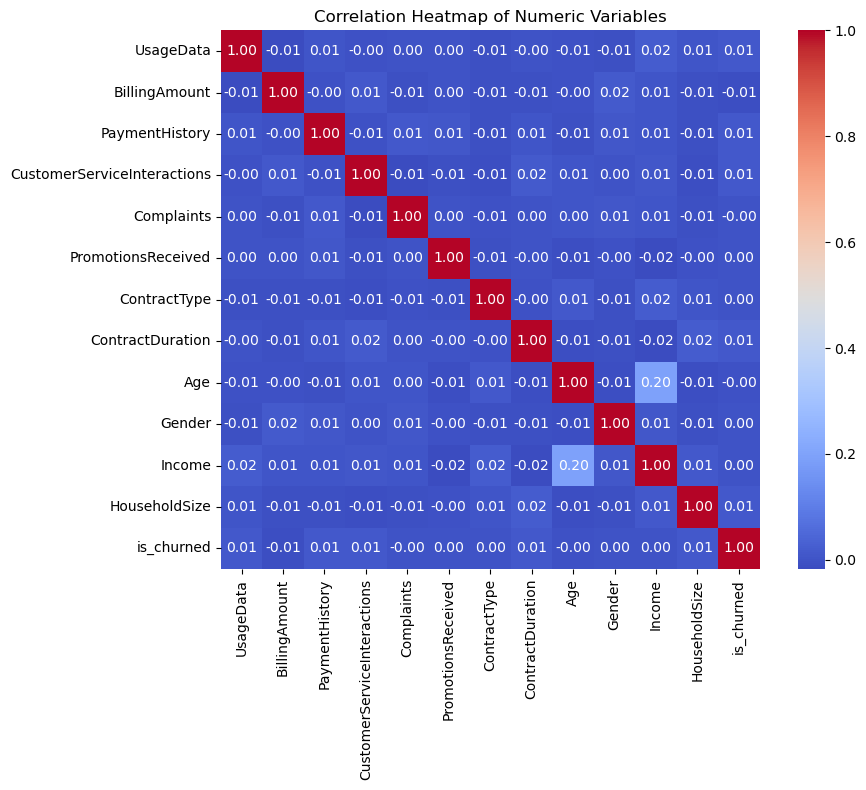

In [112]:
# let's drop month column as of now
corr_df = df_feature_eng.drop(columns=['Month'])

# Compute correlation matrix (numeric variables only)
corr = corr_df.select_dtypes(include=['number']).corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()

Due to weak correlation of each variable let's try to introduce some composite variables such as-

1. *CostPerUnit* - Feature would tell us if the user is getting a good deal in thier contract & if costPerUnit is high they might consider churning
2. *HighEnergyUsers* - Feature would tell us if someone who have higher energy usage(above 75% quantile) & might be at risk of churning due to expansive bills.
3. *BilltoIncomeRatio* - Feature would help us understanding if a particular customer would be able to afford the electricity bill.
4. *shortTermContracts* - Generally, short term contracts users have higher probability of churning.

In [ ]:
df_feature_eng['HighUsageFlag'] = (df_feature_eng['UsageData'] > df_feature_eng['UsageData'].quantile(0.75)).astype(int)

In [114]:
df_feature_eng['CostPerUnit'] = df_feature_eng['BillingAmount'] / df_feature_eng['UsageData']
df_feature_eng['BilltoIncomeRatio'] = df_feature_eng['Income'] / df_feature_eng['BillingAmount']

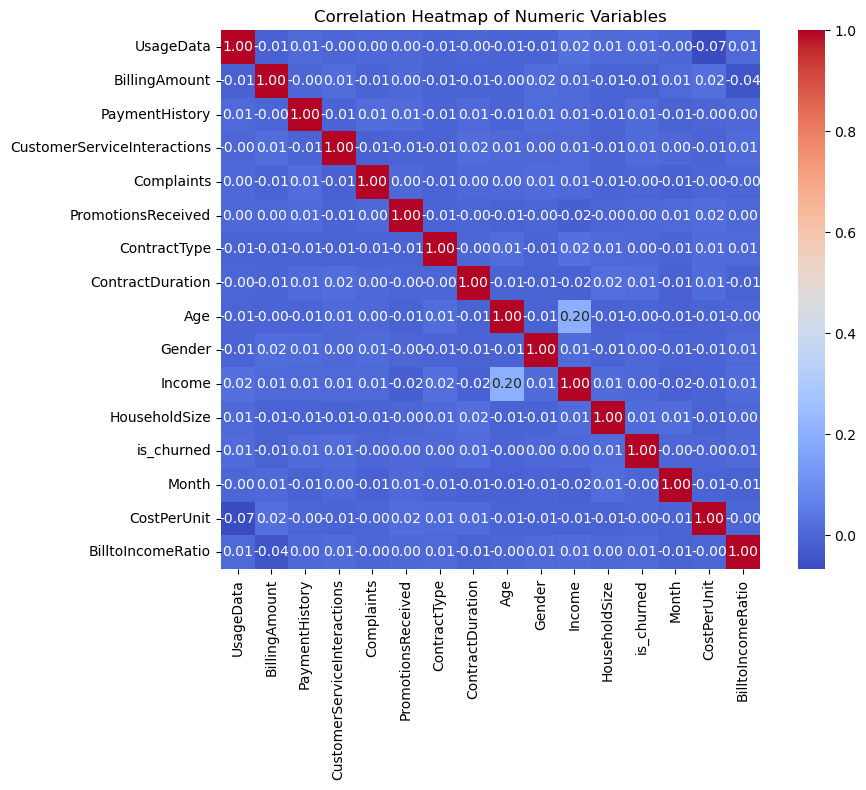

In [117]:
# Compute correlation matrix (numeric variables only)
corr = df_feature_eng.select_dtypes(include=['number']).corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()

In [118]:
df_feature_eng.head()

,UsageData,BillingAmount,PaymentHistory,CustomerServiceInteractions,Complaints,PromotionsReceived,ContractType,ContractDuration,Age,Gender,Income,HouseholdSize,is_churned,Month,CostPerUnit,BilltoIncomeRatio
0,880.922970,NaN,1,2,0,0,1,16,18,0,57732,2,0,1,NaN,NaN
1,NaN,176.144725,1,1,0,2,1,12,51,0,84085,3,0,1,NaN,477.363145
2,311.763191,145.690171,1,2,0,0,0,15,21,1,51898,5,0,1,0.467310,356.221697
3,414.412773,105.305217,1,4,1,3,1,13,23,0,72227,3,0,1,0.254107,685.882448
4,244.697028,52.308319,1,5,2,3,0,17,41,1,37707,1,0,1,0.213768,720.860481
